# Credit Card Fraud Detection using ML and DL and Grid Search CV


In [37]:
import pandas as pd


In [38]:
df = pd.read_csv('/content/creditcard.csv')

In [39]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [40]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
105062,69348,1.255690,-1.393540,0.692738,-1.289430,-1.682706,-0.276840,-1.136732,-0.076399,-1.738348,...,0.039513,0.368717,-0.072065,0.106986,0.257991,-0.087901,0.054217,0.043817,116.00,0.0
105063,69349,-1.250199,0.123183,1.051709,-0.236427,1.611834,0.284241,0.288190,0.303990,-0.430526,...,0.034681,-0.039897,-0.049460,-1.399614,0.217418,-0.496523,-0.042176,0.161224,3.99,0.0
105064,69349,-1.925153,-0.140133,2.456659,0.148112,-0.284164,-0.150520,-1.129736,1.003991,-0.218409,...,0.447094,0.895815,-0.233737,0.262490,0.050375,0.515140,0.207773,-0.090777,4.69,0.0
105065,69349,1.277856,-0.027651,0.249167,0.697814,-0.232188,-0.118324,-0.145313,-0.048568,0.677505,...,-0.141950,-0.164073,-0.194695,-0.381716,0.696330,0.489582,-0.017759,0.002991,10.00,0.0
105066,69350,-1.176438,0.811442,0.539281,-1.505794,0.401363,0.202677,0.284898,0.547988,-0.438512,...,0.077511,0.008094,-0.020608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105067 entries, 0 to 105066
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    105067 non-null  int64  
 1   V1      105067 non-null  float64
 2   V2      105067 non-null  float64
 3   V3      105067 non-null  float64
 4   V4      105067 non-null  float64
 5   V5      105067 non-null  float64
 6   V6      105067 non-null  float64
 7   V7      105067 non-null  float64
 8   V8      105067 non-null  float64
 9   V9      105067 non-null  float64
 10  V10     105067 non-null  float64
 11  V11     105067 non-null  float64
 12  V12     105067 non-null  float64
 13  V13     105067 non-null  float64
 14  V14     105067 non-null  float64
 15  V15     105067 non-null  float64
 16  V16     105067 non-null  float64
 17  V17     105067 non-null  float64
 18  V18     105067 non-null  float64
 19  V19     105067 non-null  float64
 20  V20     105067 non-null  float64
 21  V21     10

In [42]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,105067.000000,...,105067.000000,105067.000000,105067.000000,105066.000000,105066.000000,105066.000000,105066.000000,105066.000000,105066.000000,105066.000000
mean,43680.301455,-0.258318,-0.029705,0.683599,0.156974,-0.283527,0.098924,-0.116800,0.057275,-0.050479,...,-0.029851,-0.105483,-0.037181,0.009834,0.133576,0.026062,0.001671,0.001795,96.626111,0.002208
std,17527.890732,1.851801,1.650087,1.319498,1.345212,1.351589,1.301365,1.214204,1.236547,1.112787,...,0.744325,0.639981,0.626223,0.595669,0.440315,0.491947,0.392645,0.321359,262.315215,0.046939
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,33975.500000,-1.024715,-0.598212,0.178273,-0.714182,-0.907139,-0.644227,-0.606695,-0.135125,-0.696261,...,-0.223703,-0.531229,-0.177131,-0.323208,-0.130802,-0.323481,-0.061425,-0.005146,7.160000,0.000000
50%,45510.000000,-0.260627,0.075873,0.759148,0.184867,-0.318318,-0.153233,-0.072970,0.077001,-0.118121,...,-0.056348,-0.081414,-0.049651,0.065708,0.172075,-0.069141,0.010581,0.023346,25.500000,0.000000
75%,57712.000000,1.154766,0.735425,1.385199,1.026157,0.245212,0.494042,0.409551,0.368539,0.549453,...,0.121112,0.315794,0.080780,0.407051,0.421563,0.295664,0.084462,0.076727,87.540000,0.000000
max,69350.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,27.202839,10.503090,19.002942,4.016342,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


In [43]:
df.size

3257077

In [44]:
df.index

RangeIndex(start=0, stop=105067, step=1)

In [45]:
df.nunique()

,0
Time,47354
V1,102352
V2,102352
V3,102352
V4,102352
V5,102352
V6,102352
V7,102352
V8,102352
V9,102352


In [46]:
df.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [47]:
import matplotlib.pyplot as plt


In [48]:
import seaborn as sns

<Axes: xlabel='Amount', ylabel='Count'>

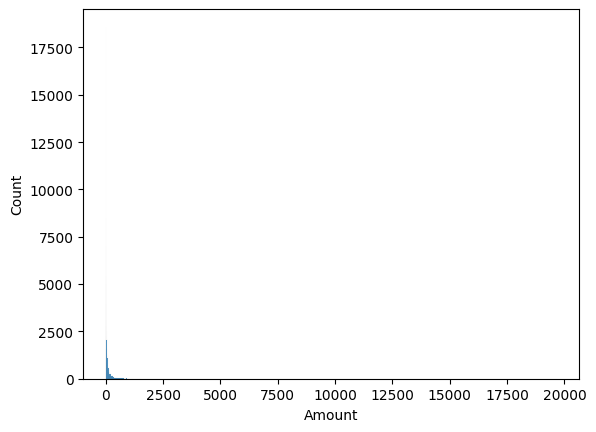

In [49]:
sns.histplot(df['Amount'])

<Axes: ylabel='Amount'>

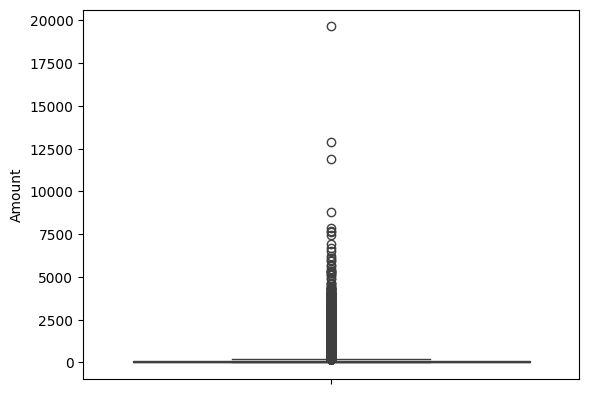

In [50]:
sns.boxplot(df['Amount'])

In [51]:
df['Class'].value_counts()

,count
Class,
0.0,104834
1.0,232


In [52]:
df.shape

(105067, 31)

In [53]:
label_df=df['Class'].value_counts().index

In [54]:
values_df=df['Class'].value_counts().values

([<matplotlib.patches.Wedge at 0x7f30f1883690>,
 [Text(-1.0999735334844212, 0.0076305723112638675, '0.0'),
  Text(1.0999735341515027, -0.007630476148519611, '1.0')],
 [Text(-0.5999855637187751, 0.0041621303515984726, '99.78%'),
  Text(0.5999855640826377, -0.004162077899192515, '0.22%')])

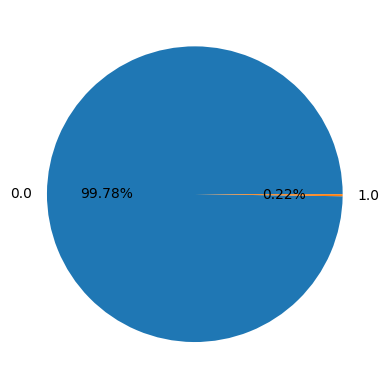

In [55]:
plt.pie(values_df,labels=label_df,autopct='%1.2f%%')

In [56]:
df.drop('Time',axis=1,inplace=True)

In [57]:
df.groupby('Class')['Amount'].mean()

,Amount
Class,
0.0,96.584297
1.0,115.520474


In [58]:
label_df=df.groupby('Class')['Amount'].mean().index

In [59]:
values_df=df.groupby('Class')['Amount'].mean().values

([<matplotlib.patches.Wedge at 0x7f30f5e7ea10>,
 [Text(0.15375523523135048, 1.0892012337667234, '0.0'),
  Text(-0.1537553996961594, -1.0892012105503162, '1.0')],
 [Text(0.08386649194437298, 0.5941097638727582, '45.54%'),
  Text(-0.08386658165245056, -0.5941097512092633, '54.46%')])

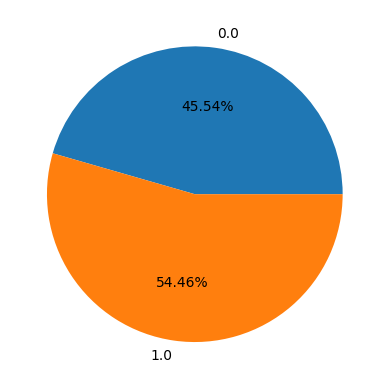

In [60]:
plt.pie(values_df,labels=label_df,autopct='%1.2f%%')

In [61]:
df.groupby('Class').size()

,0
Class,
0.0,104834
1.0,232


In [62]:
#SMOTE
from imblearn.over_sampling import SMOTE

In [63]:
sm = SMOTE(random_state=42)

In [64]:
df.dropna(inplace=True)

In [65]:
X=df.drop('Class',axis=1)

In [66]:
y=df['Class']

In [67]:
X,y=sm.fit_resample(X,y)

In [68]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209663,0.004979,1.708458,-2.459875,3.771091,-1.543926,-0.765889,-3.249110,0.953647,-2.231134,-3.475346,...,0.345926,0.759478,0.288233,-0.172769,-0.097824,0.670192,0.148507,0.743204,0.370223,5.524081
209664,-1.363607,4.725918,-6.081182,5.859628,1.235007,-2.907655,-1.707464,0.498206,-3.635810,-7.110418,...,0.579366,0.555736,-0.448051,-0.720544,-0.397009,1.228538,0.376865,0.856222,0.551723,1.000000
209665,-0.117017,1.252042,-1.732908,2.149678,-0.349216,-0.404025,-1.894207,0.416964,-1.859484,-1.814353,...,0.488516,0.414533,0.241404,-0.240599,-0.719014,0.253669,0.027579,0.431585,0.198107,21.143348
209666,-27.523011,15.428216,-28.658415,6.411609,-20.134277,-4.803735,-19.048886,18.111544,-3.681339,-8.047475,...,1.692643,1.799106,-2.038164,-1.264033,0.164675,1.968936,-0.212475,1.335726,0.391284,99.990000


In [69]:
y

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
209663,1.0
209664,1.0
209665,1.0
209666,1.0


In [70]:
X.shape

(209668, 29)

In [71]:
y.shape

(209668,)

In [72]:
y.value_counts()

,count
Class,
0.0,104834
1.0,104834


In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
rfc = RandomForestClassifier()

In [77]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [78]:
y_pred = rfc.predict(X_test)

In [79]:
y_pred

array([0., 0., 0., ..., 1., 1., 1.])

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
accuracy_score(y_test,y_pred)*100

99.99421890130219

In [86]:
from sklearn.neighbors import KNeighborsClassifier

In [87]:
knn = KNeighborsClassifier(n_neighbors=5)

In [88]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [89]:
y_pred = knn.predict(X_test)

In [107]:
from sklearn.metrics import confusion_matrix

In [108]:
confusion_matrix(y_test,y_pred)

array([[33804,   584],
       [ 1781, 33022]])

In [109]:
from sklearn.metrics import classification_report

In [111]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97     34388
         1.0       0.98      0.95      0.97     34803

    accuracy                           0.97     69191
   macro avg       0.97      0.97      0.97     69191
weighted avg       0.97      0.97      0.97     69191



In [90]:
y_pred

array([0., 0., 0., ..., 1., 1., 1.])

In [91]:
accuracy_score(y_test,y_pred)*100

99.82223121504242

In [92]:
from sklearn.tree import DecisionTreeClassifier

In [93]:
dtc = DecisionTreeClassifier()

In [94]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [95]:
y_pred = dtc.predict(X_test)

In [96]:
y_pred

array([0., 0., 0., ..., 1., 1., 1.])

In [97]:
accuracy_score(y_test,y_pred)*100

99.86269890592708

In [98]:
from sklearn.linear_model import LogisticRegression

In [99]:
le = LogisticRegression()

In [100]:
le.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [101]:
y_pred = le.predict(X_test)

In [102]:
y_pred

array([0., 0., 0., ..., 1., 1., 1.])

In [103]:
accuracy_score(y_test,y_pred)*100

96.58192539492131

#Deep Learning

In [132]:
import keras

In [133]:
print(keras.__version__)

3.8.0


In [134]:
model = keras.Sequential()

In [135]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [136]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209663,0.004979,1.708458,-2.459875,3.771091,-1.543926,-0.765889,-3.249110,0.953647,-2.231134,-3.475346,...,0.345926,0.759478,0.288233,-0.172769,-0.097824,0.670192,0.148507,0.743204,0.370223,5.524081
209664,-1.363607,4.725918,-6.081182,5.859628,1.235007,-2.907655,-1.707464,0.498206,-3.635810,-7.110418,...,0.579366,0.555736,-0.448051,-0.720544,-0.397009,1.228538,0.376865,0.856222,0.551723,1.000000
209665,-0.117017,1.252042,-1.732908,2.149678,-0.349216,-0.404025,-1.894207,0.416964,-1.859484,-1.814353,...,0.488516,0.414533,0.241404,-0.240599,-0.719014,0.253669,0.027579,0.431585,0.198107,21.143348
209666,-27.523011,15.428216,-28.658415,6.411609,-20.134277,-4.803735,-19.048886,18.111544,-3.681339,-8.047475,...,1.692643,1.799106,-2.038164,-1.264033,0.164675,1.968936,-0.212475,1.335726,0.391284,99.990000


In [137]:
model.add(
    keras.Input(
        shape=(29,),
        batch_size=32
    )
)

In [138]:
model.add(                                 #hidden layer
    keras.layers.Dense(
    64,
    activation='relu'
))

In [139]:
model.add(                      # hidden layer
    keras.layers.Dense(
    128,
    activation='relu'
))

In [140]:
model.add(                         ## Output layer
        keras.layers.Dense(
    1,
    activation='sigmoid'
)
)

In [141]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (32, 64)               │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 128)              │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,369 (40.50 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [143]:
callback=keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=0,
    restore_best_weights=True,
)              ## it will increase accuracy

In [144]:
model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=100,
    verbose="auto",
    validation_data=(X_test,y_test),
    callbacks=[callback]
)

Epoch 1/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9601 - loss: 0.2435 - val_accuracy: 0.9850 - val_loss: 0.1783
Epoch 2/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9923 - loss: 0.0500 - val_accuracy: 0.9947 - val_loss: 0.0200
Epoch 3/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9954 - loss: 0.0185 - val_accuracy: 0.9987 - val_loss: 0.0071
Epoch 4/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9968 - loss: 0.0127 - val_accuracy: 0.9752 - val_loss: 0.1109
Epoch 5/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9973 - loss: 0.0092 - val_accuracy: 0.9985 - val_loss: 0.0053
Epoch 6/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9991 - val_loss: 0.0038
Epoch 7/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9982 - loss: 0.0061 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 8/100
4390/4390 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9988 -

In [145]:
model.evaluate(X_test,y_test)

2163/2163 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9992 - loss: 0.0032


[0.003039827337488532, 0.9992629289627075]

#Grid Search CV

In [147]:
from sklearn.model_selection import GridSearchCV

In [148]:
from sklearn.ensemble import RandomForestClassifier

In [149]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

In [151]:
rfc = RandomForestClassifier()

In [152]:
model = GridSearchCV(rfc, param_grid, cv=5,n_jobs=-1)

In [153]:
model.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200]})

In [154]:
y_pred = model.predict(X_test)

In [155]:
accuracy_score(y_test,y_pred)*100

99.99277362662774

In [156]:
param_grid = {
    'criterion': ['gini', 'entropy]
}


In [157]:
from sklearn.tree import DecisionTreeClassifier

In [158]:
dtc = DecisionTreeClassifier()

In [159]:
model = GridSearchCV(dtc, param_grid, cv=5,n_jobs=-1)